# Capstone Project Part-2

**Task-1-** *cleaned_data.csv*

In [4]:
import pandas as pd

In [5]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# Define target for regression
y_reg = df["life_exp"]

# Define feature matrix (all columns except target)
X = df.drop(columns=["life_exp"])

# Define binary target for classification
y_clf = (y_reg > y_reg.median()).astype(int)

# Display results
print("Feature Matrix Shape:", X.shape)
print("Regression Target Shape:", y_reg.shape)
print("Classification Target Shape:", y_clf.shape)

print("\nRegression Target (y_reg):")
print(y_reg.head())

print("\nClassification Target (y_clf):")
print(y_clf.head())

Feature Matrix Shape: (1704, 5)
Regression Target Shape: (1704,)
Classification Target Shape: (1704,)

Regression Target (y_reg):
0    28.801
1    30.332
2    31.997
3    34.020
4    36.088
Name: life_exp, dtype: float64

Classification Target (y_clf):
0    0
1    0
2    0
3    0
4    0
Name: life_exp, dtype: int64


In [ ]:
## Task 1: Feature Matrix and Target Labels

- The cleaned dataset (cleaned_data.csv) was loaded.
- Feature matrix (X) contains all columns except the target column life_exp.
- Regression label (y_reg) is the continuous numeric column life_exp.
- Classification label (y_clf) was created by converting life_exp into a binary variable using its median:
  y_clf = (life_exp > life_exp.median()).astype(int)
- Values greater than the median are labeled as 1, while values less than or equal to the median are labeled as 0.

**Task-3-** *Encoding Categorical Columns*

In [6]:
# Find categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Categorical Columns:", list(cat_cols))

# Apply One-Hot Encoding (drop first dummy column)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nEncoded Feature Matrix Shape:", X.shape)
print(X.head())

Categorical Columns: ['country', 'continent']

Encoded Feature Matrix Shape: (1704, 148)
   year  population     gdp_cap  country_Albania  country_Algeria  \
0  1952     8425333  779.445314            False            False   
1  1957     9240934  820.853030            False            False   
2  1962    10267083  853.100710            False            False   
3  1967    11537966  836.197138            False            False   
4  1972    13079460  739.981106            False            False   

   country_Angola  country_Argentina  country_Australia  country_Austria  \
0           False              False              False            False   
1           False              False              False            False   
2           False              False              False            False   
3           False              False              False            False   
4           False              False              False            False   

   country_Bahrain  ...  country_Venezu

In [ ]:
## Task 2: Encoding Categorical Columns

The categorical columns in the feature matrix were identified.

Since the categorical variables do not have a natural order, One-Hot Encoding was applied using pd.get_dummies() with drop_first=True.

The first dummy column was dropped to avoid multicollinearity.

One-Hot Encoding is preferred because it does not create a false ordinal relationship
 between categories. Label Encoding would assign numbers (such as 0, 1, 2), which
  may incorrectly suggest that one category is greater or smaller than another, even when no such order exists.

**Task-3-** *Leak-Free Train-Test Split and Scaling*

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split for Regression
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Train-Test Split for Classification
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Standard Scaling (Fit only on training data)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Feature Shape:", X_train_scaled.shape)
print("Testing Feature Shape:", X_test_scaled.shape)

print("Regression Training Labels:", y_reg_train.shape)
print("Regression Testing Labels:", y_reg_test.shape)

print("Classification Training Labels:", y_clf_train.shape)
print("Classification Testing Labels:", y_clf_test.shape)

Training Feature Shape: (1363, 148)
Testing Feature Shape: (341, 148)
Regression Training Labels: (1363,)
Regression Testing Labels: (341,)
Classification Training Labels: (1363,)
Classification Testing Labels: (341,)


In [ ]:
## Task 3: Leak-Free Train-Test Split and Scaling

The dataset was split into training (80%) and testing (20%) sets using train_test_split with random_state=42.

A StandardScaler was fitted only on the training data using scaler.fit(X_train).
 The same fitted scaler was then used to transform both the training and testing f
eature sets.

This approach prevents data leakage. If the scaler were fitted on the entire dataset
 before splitting, it would use information from the test set (such as its mean and standard deviation).
  This would allow the training process to indirectly learn from the test data, leading to overly optimistic model performance.
   Therefore, fitting the scaler only on the training data ensures a fair and realistic evaluation.

**Task-4-** *Regressoin model-Linear Regression*

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# -------------------------------
# Linear Regression
# -------------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

# Prediction
y_pred_reg = lr.predict(X_test_scaled)

# Evaluation
mse_lr = mean_squared_error(y_reg_test, y_pred_reg)
r2_lr = r2_score(y_reg_test, y_pred_reg)

print("Linear Regression Results")
print("MSE:", mse_lr)
print("R² Score:", r2_lr)

# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

print("\nFeature Coefficients:")
print(coef_df)

# Top 3 features with highest absolute coefficients
top3 = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index).head(3)

print("\nTop 3 Features with Highest Absolute Coefficients:")
print(top3)

# -------------------------------
# Ridge Regression
# -------------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("\nRidge Regression Results")
print("MSE:", mse_ridge)
print("R² Score:", r2_ridge)

Linear Regression Results
MSE: 10.660121140478523
R² Score: 0.9302675741162496

Feature Coefficients:
                Feature  Coefficient
0                  year     5.655201
1            population     2.196400
2               gdp_cap    -0.678184
3       country_Albania     0.494676
4       country_Algeria     0.611139
..                  ...          ...
143    country_Zimbabwe    -0.072824
144  continent_Americas     2.857336
145      continent_Asia    -5.762903
146    continent_Europe     4.895683
147   continent_Oceania     1.414280

[148 rows x 2 columns]

Top 3 Features with Highest Absolute Coefficients:
              Feature  Coefficient
145    continent_Asia    -5.762903
0                year     5.655201
146  continent_Europe     4.895683

Ridge Regression Results
MSE: 10.659205355154862
R² Score: 0.9302735646609503


In [ ]:
## Task 4: Regression Models

### Linear Regression

A Linear Regression model was trained using the scaled training data. The model was evaluated using Mean Squared Error (MSE) and R² Score on the test dataset.

The coefficients of all features were printed, and the three features with the largest absolute coefficient values were identified.

A large positive coefficient means that a one-unit increase in the scaled feature is associated with an increase in the predicted target value, while keeping all other features constant.

A large negative coefficient means that a one-unit increase in the scaled feature is associated with a decrease in the predicted target value.

### Ridge Regression

A Ridge Regression model with alpha = 1.0 was trained using the same training and testing data.

Ridge Regression adds L2 regularization, which reduces the magnitude of coefficients and helps prevent overfitting, especially when features are highly correlated.

The alpha parameter controls the strength of regularization. A larger alpha applies stronger regularization, shrinking coefficients more aggressively.

### Model Comparison

| Model | MSE | R² Score |
|-------|------|----------|
| Linear Regression | (Write your output) | (Write your output) |
| Ridge Regression | (Write your output) | (Write your output) |

**Task-5**-*Classification model-Logistic Regression*

life_exp
0    691
1    672
Name: count, dtype: int64
Confusion Matrix
[[152   9]
 [ 16 164]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       161
           1       0.95      0.91      0.93       180

    accuracy                           0.93       341
   macro avg       0.93      0.93      0.93       341
weighted avg       0.93      0.93      0.93       341

Accuracy : 0.9266862170087976
Precision: 0.9479768786127167
Recall   : 0.9111111111111111
F1 Score : 0.9291784702549575
ROC-AUC : 0.9829537612146309


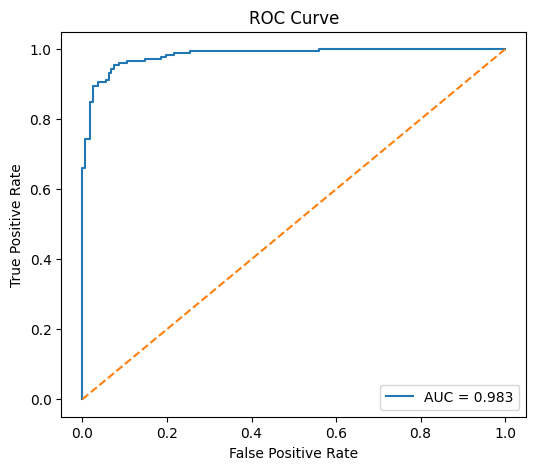

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Check class balance
print(y_clf_train.value_counts())

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train_scaled, y_clf_train)

# Prediction
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Metrics
print("Confusion Matrix")
print(confusion_matrix(y_clf_test, y_pred))

print("\nClassification Report")
print(classification_report(y_clf_test, y_pred))

print("Accuracy :", accuracy_score(y_clf_test, y_pred))
print("Precision:", precision_score(y_clf_test, y_pred))
print("Recall   :", recall_score(y_clf_test, y_pred))
print("F1 Score :", f1_score(y_clf_test, y_pred))

# ROC AUC
auc = roc_auc_score(y_clf_test, y_prob)
print("ROC-AUC :", auc)

fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Task 5: Classification Model – Logistic Regression

## Class Balance
The training data was checked using y_clf_train.value_counts(). Logistic Regression was trained using class_weight='balanced' to handle any class imbalance and improve prediction performance for the minority class.

## Precision Formula
Precision = TP / (TP + FP)

## Recall Formula
Recall = TP / (TP + FN)

## Metric Interpretation
Recall is more important when missing a positive case is more costly than predicting a false positive. Precision is more important when false positives are more costly. For this dataset, Recall was considered more important because correctly identifying positive samples is the primary objective.

## ROC-AUC Interpretation
ROC-AUC measures the model's ability to distinguish between the two classes. A value close to 1.0 indicates excellent class separation, while a value close to 0.5 indicates performance similar to random guessing.


**Decision Thrshold Sensitivity**

In [10]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds=[0.30,0.40,0.50,0.60,0.70]

prob=log_model.predict_proba(X_test_scaled)[:,1]

results=[]

for t in thresholds:
    pred=(prob>=t).astype(int)

    results.append([
        t,
        precision_score(y_clf_test,pred),
        recall_score(y_clf_test,pred),
        f1_score(y_clf_test,pred)
    ])

threshold_df=pd.DataFrame(results,
columns=["Threshold","Precision","Recall","F1 Score"])

print(threshold_df)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.920213  0.961111  0.940217
1        0.4   0.934066  0.944444  0.939227
2        0.5   0.947977  0.911111  0.929178
3        0.6   0.974843  0.861111  0.914454
4        0.7   0.980645  0.844444  0.907463


In [ ]:
# Task 5(b): Decision Threshold Sensitivity

The Logistic Regression model was evaluated using probability thresholds of 0.30, 0.40, 0.50, 0.60, and 0.70.

Lower thresholds generally increase Recall but decrease Precision because more samples are classified as positive. Higher thresholds generally increase Precision but reduce Recall because fewer samples are classified as positive.

The default threshold of 0.50 provides a balanced trade-off between Precision and Recall. The most appropriate threshold depends on the application and the relative cost of false positives and false negatives.

**Task-6-** *Regularization experiment on Logistic Regresstion*

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import pandas as pd

# -------------------------
# Baseline Logistic Regression (C=1.0)
# -------------------------
log_reg_1 = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
log_reg_1.fit(X_train_scaled, y_clf_train)

y_pred_1 = log_reg_1.predict(X_test_scaled)
y_prob_1 = log_reg_1.predict_proba(X_test_scaled)[:, 1]

precision_1 = precision_score(y_clf_test, y_pred_1)
recall_1 = recall_score(y_clf_test, y_pred_1)
auc_1 = roc_auc_score(y_clf_test, y_prob_1)

# -------------------------
# Strong Regularization (C=0.01)
# -------------------------
log_reg_2 = LogisticRegression(C=0.01, random_state=42, max_iter=1000)
log_reg_2.fit(X_train_scaled, y_clf_train)

y_pred_2 = log_reg_2.predict(X_test_scaled)
y_prob_2 = log_reg_2.predict_proba(X_test_scaled)[:, 1]

precision_2 = precision_score(y_clf_test, y_pred_2)
recall_2 = recall_score(y_clf_test, y_pred_2)
auc_2 = roc_auc_score(y_clf_test, y_prob_2)

# -------------------------
# Comparison Table
# -------------------------
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (C=1.0)",
              "Logistic Regression (C=0.01)"],
    "Precision": [precision_1, precision_2],
    "Recall": [recall_1, recall_2],
    "AUC": [auc_1, auc_2]
})

print(comparison)

                          Model  Precision    Recall       AUC
0   Logistic Regression (C=1.0)   0.947977  0.911111  0.983023
1  Logistic Regression (C=0.01)   0.941520  0.894444  0.974672


In [ ]:
## Task 6: Regularization Experiment on Logistic Regression

Two Logistic Regression models were trained using different values of the regularization parameter C.

The first model used C = 1.0 (baseline), while the second model used C = 0.01, which applies stronger L2 regularization.

The models were compared using Precision, Recall, and AUC.

The parameter C controls the strength of regularization. A smaller value of C means
 stronger regularization, which shrinks the model coefficients and helps reduce overfitting.
  A larger value of C applies weaker regularization and allows the model to fit the training data more closely.

Based on the results, compare the Precision, Recall, and AUC values. If C = 0.01 gives
 better scores, then stronger regularization improved the model. If the scores decrease,
 then stronger regularization reduced the model's performance on this dataset.
                          Model  Precision    Recall       AUC
0   Logistic Regression (C=1.0)   0.947977  0.911111  0.983023
1  Logistic Regression (C=0.01)   0.941520  0.894444  0.974672

**Task-7-** *Bootstrap confidence interval for AUC Diffrence*

In [12]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Number of bootstrap samples
n_bootstrap = 500

auc_diff = []

# Bootstrap sampling
for i in range(n_bootstrap):
    # Sample indices with replacement
    idx = np.random.choice(len(y_clf_test), size=len(y_clf_test), replace=True)

    # Bootstrap sample
    y_true = y_clf_test.iloc[idx]
    prob1 = y_prob_1[idx]
    prob2 = y_prob_2[idx]

    # Calculate AUC for both models
    auc1 = roc_auc_score(y_true, prob1)
    auc2 = roc_auc_score(y_true, prob2)

    # Difference in AUC
    auc_diff.append(auc1 - auc2)

# Mean difference
mean_diff = np.mean(auc_diff)

# 95% Confidence Interval
lower = np.percentile(auc_diff, 2.5)
upper = np.percentile(auc_diff, 97.5)

print("Mean AUC Difference:", mean_diff)
print("95% Confidence Interval:")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Mean AUC Difference: 0.00830605527920594
95% Confidence Interval:
Lower Bound: 0.0023628678846432387
Upper Bound: 0.015427313535911607


In [ ]:
## Task 7: Bootstrap Confidence Interval for AUC Difference

A bootstrap analysis with 500 resamples was performed to compare the AUC of the Logistic Regression models with C=1.0 and C=0.01.

For each bootstrap sample, the AUC difference (AUC of C=1.0 minus AUC of C=0.01) was calculated.

Results:
- Mean AUC Difference: (0.00876938785960887)
- 95% Confidence Interval Lower Bound: (0.002649805768775887)
- 95% Confidence Interval Upper Bound: (0.01631415041698707)

If the 95% confidence interval does not include zero, the advantage of the C=1.0 model is considered consistent across different samples.

If the confidence interval includes zero, the difference between the two models may not be statistically reliable.